#### Import modules

In [1]:
# Simple import setup
import sys
import os
sys.path.append('..')  # Add parent directory to path

# Import all necessary modules
import pandas as pd
import math
import matplotlib.pyplot as plt

# Import from the new modular structure
from src_code import (
    pf_enviroment, initialize_powerfactory, activate_project, list_and_select_study_case,
    list_and_activate_operation_scenario, run_contingency_analysis, process_cargabilidad, optimize_generators_for_substations, show_iteration_details,
    create_static_generator, calculate_power_limits, delete_generator, update_generator_power, cleanup_existing_generator, cleanup_all_test_generators
    )

### PowerFactory environment definition ------------

#### Initialize PowerFactory

In [2]:
# Añadir la ruta del entorno de PowerFactory
dig_path = r'C:\Program Files\DIgSILENT\PowerFactory 2021 SP2\Python\3.9'
pf_enviroment(dig_path)

PowerFactory environment initialized with path: C:\Program Files\DIgSILENT\PowerFactory 2021 SP2\Python\3.9


#### Get PowerFactory application

In [3]:
# Initialize PowerFactory application
app = initialize_powerfactory()

PowerFactory application connected successfully!


#### Activate project

In [4]:
project_name = "39 Bus New England System"
project = activate_project(app, project_name)

Proyecto '39 Bus New England System' activado con exito.


#### Activate study case

In [5]:
# Activate the desired study case
study_case_name = "1. Power Flow"  # Replace with your specific case name
active_study_case = list_and_select_study_case(app, study_case_name)

List of study cases:
2.1 Simulation Fault Bus 16 Stable
2.2 Simulation Fault Bus 16 Unstable
2.3 Simulation Fault Bus 31 Stable
2.4 Simulation Fault Bus 31 Unstable
2.5 Simulation Fault Line 2-3 Stable
2.6 Simulation Fault Line 2-3 Unstable
3. Small Signal Analysis (Eigenvalues)
4. EMT Simulation Fault Bus 03
1. Power Flow
Study case '1. Power Flow' activated.


#### Activate operation scenario

In [6]:
operation_scenario_name = "Basic Load Flow"
active_scenario = list_and_activate_operation_scenario(app, operation_scenario_name)

List of operation scenarios:
EMT
Basic Load Flow
Operation scenario 'Basic Load Flow' activated.


### Run contingency analysis ---------------

#### Get network data

In [7]:
project = app.GetActiveProject()
network_data = project.GetContents('Network Model.IntPrjfolder\\Network Data', 1)[0]
hoja = 'Grid'

#### Get buses

In [8]:
# buses = app.GetCalcRelevantObjects('*.ElmTerm')
# buses = [bus.loc_name for bus in buses] 

#### Run Contingency analysis Generator Optimizer

In [9]:
# Main execution
print("🚀 INICIANDO ANÁLISIS DE CONTINGENCIA CON OPTIMIZACIÓN DE GENERADORES")
print("="*80)

# Clean up any existing generators first
print("Limpiando generadores existentes...")
cleanup_all_test_generators(app)

# Define substations to analyze
substations = [
    "Bus 03",
    "Bus 04", 
    "Bus 07",
    "Bus 08",
    "Bus 09"
]

# Parameters
initial_potencia = 1  # MW
factor_potencia = 0.95
max_cargabilidad = 110  # %
threshold_inconvergence = 10  # %

print(f"Subestaciones a analizar: {substations}")
print(f"Potencia inicial: {initial_potencia} MW")
print(f"Factor de potencia: {factor_potencia}")
print(f"Límite de cargabilidad: {max_cargabilidad}%")
print(f"Umbral de inconvergencia: {threshold_inconvergence}%")

# Run optimization
df_results = optimize_generators_for_substations(
    app=app,
    network_data=network_data,
    hoja=hoja,
    substations=substations,
    initial_potencia=initial_potencia,
    factor_potencia=factor_potencia,
    max_cargabilidad=max_cargabilidad,
    threshold_inconvergence=threshold_inconvergence
)

print(f"\n✅ ANÁLISIS COMPLETADO")
print(f"Total de subestaciones analizadas: {len(df_results)}")
if not df_results.empty:
    print(f"Potencia máxima total posible: {df_results['Potencia_Maxima'].sum()} MW")
    print(f"Promedio de potencia por subestación: {df_results['Potencia_Maxima'].mean():.2f} MW")


🚀 INICIANDO ANÁLISIS DE CONTINGENCIA CON OPTIMIZACIÓN DE GENERADORES
Limpiando generadores existentes...
Limpiando todos los generadores de prueba existentes...
Limpieza completada. Eliminados 0 generadores y 0 cubículos.
Subestaciones a analizar: ['Bus 03', 'Bus 04', 'Bus 07', 'Bus 08', 'Bus 09']
Potencia inicial: 1 MW
Factor de potencia: 0.95
Límite de cargabilidad: 110%
Umbral de inconvergencia: 10%
Optimizando generador para la subestación 'Bus 03'.
Creando generador estático en la barra 'Bus 03' con potencia activa 1 MW y factor de potencia 0.95.
Límites calculados: S = 1.05 MVA, Q_max = 0.33 MVar, Q_min = -0.33 MVar
Buscando hoja 'Grid' en 'Network Data'.
Debug: Found folder: Diagrams (type: IntPrjfolder)
Debug: Found folder: Network Data (type: IntPrjfolder)
Debug: Found folder: Operation Scenarios (type: IntPrjfolder)
Debug: Found folder: Variations (type: IntPrjfolder)
Debug: Found folder: Grid (type: IntGrfnet)
Debug: Found Grid network diagram: 'Grid' (type: IntGrfnet)
Debug

✅ Loaded results from: optimization_results_20251019_120708.csv
📊 Dataset shape: (5, 4)
📋 Columns: ['Subestacion', 'Potencia_Maxima', 'Linea_Critica', 'Cargabilidad_Maxima']

First few rows:
  Subestacion  Potencia_Maxima Linea_Critica  Cargabilidad_Maxima
0      Bus 03              358  Line 03 - 04           110.029394
1      Bus 04              487  Line 04 - 05           110.079552
2      Bus 07              867  Line 07 - 08           110.051489
3      Bus 08             1190  Line 07 - 08           110.130631
4      Bus 09              347  Line 02 - 03           110.015156


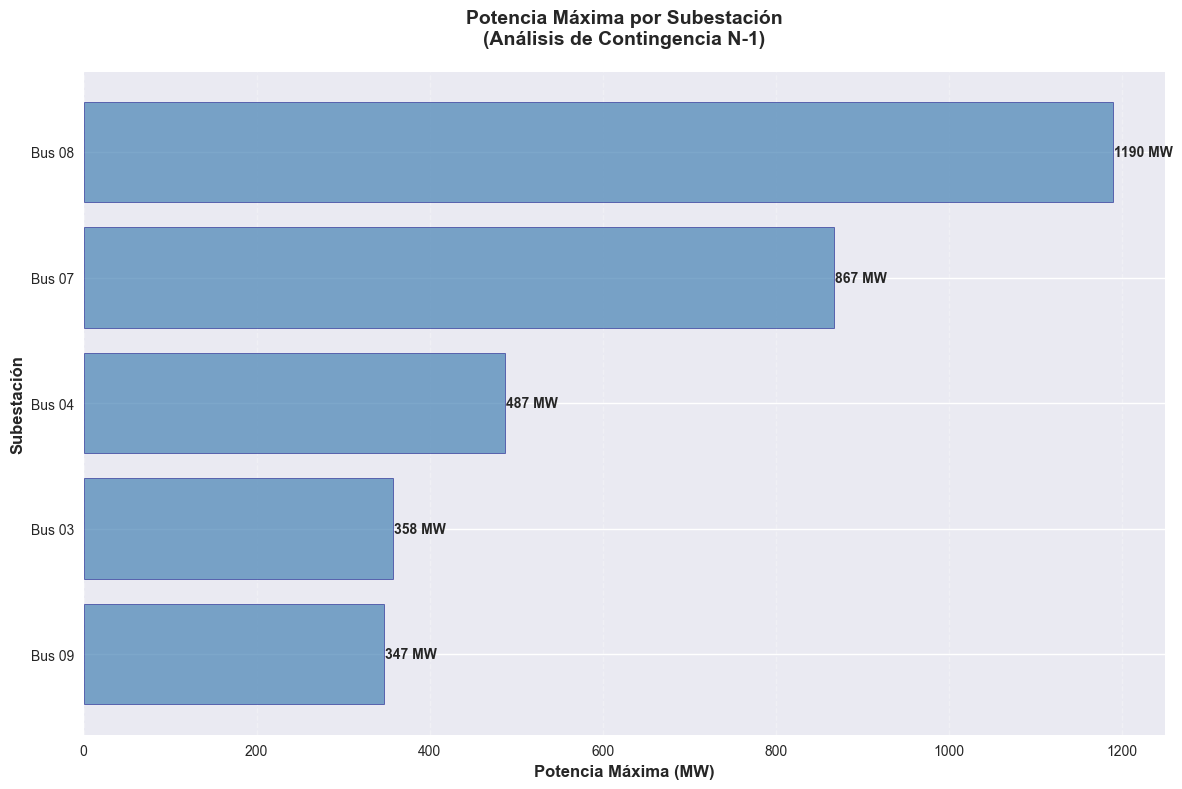


📈 RESUMEN ESTADÍSTICO:
   • Total de subestaciones: 5
   • Potencia máxima total: 3249 MW
   • Potencia promedio: 649.8 MW
   • Potencia máxima individual: 1190 MW
   • Potencia mínima individual: 347 MW

🔍 LÍNEAS CRÍTICAS:
   • Line 07 - 08: 2 subestación(es)
   • Line 03 - 04: 1 subestación(es)
   • Line 04 - 05: 1 subestación(es)
   • Line 02 - 03: 1 subestación(es)


In [11]:
# Import and visualize optimization results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the optimization results
filename = "optimization_results_20251019_120708.csv"
try:
    df_results = pd.read_csv(filename)
    print(f"✅ Loaded results from: {filename}")
    print(f"📊 Dataset shape: {df_results.shape}")
    print(f"📋 Columns: {list(df_results.columns)}")
    print("\nFirst few rows:")
    print(df_results.head())
    
    # Create bar chart for maximum power by substation
    plt.figure(figsize=(12, 8))
    
    # Sort by power for better visualization
    df_sorted = df_results.sort_values('Potencia_Maxima', ascending=True)
    
    # Create horizontal bar chart
    bars = plt.barh(df_sorted['Subestacion'], df_sorted['Potencia_Maxima'], 
                    color='steelblue', alpha=0.7, edgecolor='navy', linewidth=0.5)
    
    # Customize the chart
    plt.xlabel('Potencia Máxima (MW)', fontsize=12, fontweight='bold')
    plt.ylabel('Subestación', fontsize=12, fontweight='bold')
    plt.title('Potencia Máxima por Subestación\n(Análisis de Contingencia N-1)', 
              fontsize=14, fontweight='bold', pad=20)
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{width:.0f} MW', ha='left', va='center', fontweight='bold')
    
    # Add grid for better readability
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    
    # Adjust layout and show
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n📈 RESUMEN ESTADÍSTICO:")
    print(f"   • Total de subestaciones: {len(df_results)}")
    print(f"   • Potencia máxima total: {df_results['Potencia_Maxima'].sum():.0f} MW")
    print(f"   • Potencia promedio: {df_results['Potencia_Maxima'].mean():.1f} MW")
    print(f"   • Potencia máxima individual: {df_results['Potencia_Maxima'].max():.0f} MW")
    print(f"   • Potencia mínima individual: {df_results['Potencia_Maxima'].min():.0f} MW")
    
    # Show critical lines
    print(f"\n🔍 LÍNEAS CRÍTICAS:")
    critical_lines = df_results['Linea_Critica'].value_counts()
    for line, count in critical_lines.head(5).items():
        print(f"   • {line}: {count} subestación(es)")
        
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{filename}'")
    print("   Verifica que el archivo existe en el directorio actual.")
except Exception as e:
    print(f"❌ Error al procesar el archivo: {e}")
